# Polarisation Curves

## Imports

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from redoxed.data_loading.data_loaders import LoaderFactory, BiologicLoader, CSVLoader
from redoxed.plots import GenericPlot, PolarisationPlot
from redoxed.dc import PolarisationData

# set latex mode
from redoxed import config
config.set_latex_mode(False)  

## Data Loading

Polarisation data can be directly loaded from user-extracted j and V arrays:

```python
PolarisationData(j=j_array, V=V_array, A=cell_area)
```

However, redoxED also allows (mostly) automated extraction from GCPL data. 

At present, conversion functions have been written for converting polarisation data collected using galvanostatic cycling (GCPL) measurements conducted on Biologic potentiostats.

It is advisable to check the shape of pulses before converting:


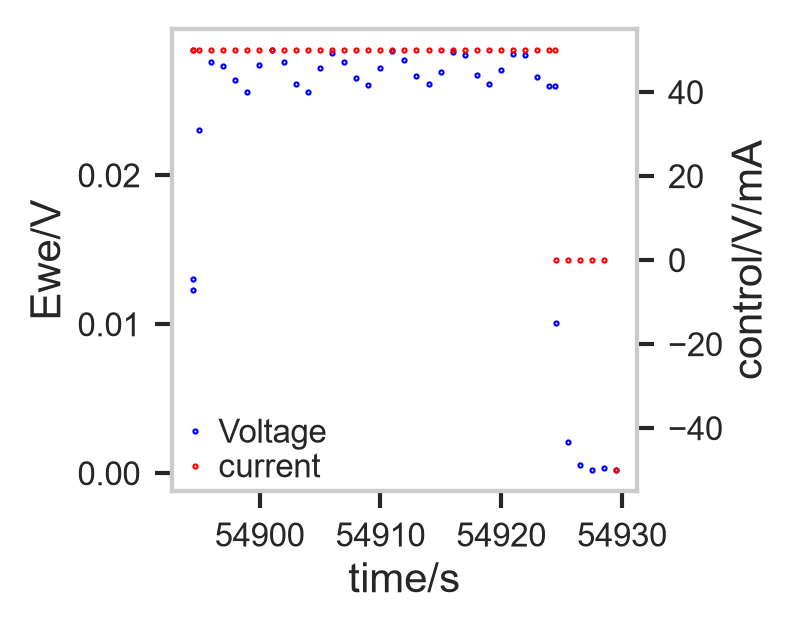

In [21]:
fpath = "../data/pol_data_raw.mpr"
ECData_object = BiologicLoader().load_data(fpath=fpath)
# display(ECData_object.df)

GenericPlot_object = GenericPlot(x_col="time/s", y_col="Ewe/V", y2_col="control/V/mA", figsize = (2,2))

GenericPlot_object.ax.set_xlabel("time/s")
GenericPlot_object.ax.set_ylabel("Ewe/V")
GenericPlot_object.ax.tick_params(
            axis="both",
            which="both",
            bottom=True,
            left=True,
        )
if GenericPlot_object.ax2 is None:
    GenericPlot_object.ax2 = GenericPlot_object.ax.twinx()
    GenericPlot_object.ax2.set_ylabel("control/V/mA")
    GenericPlot_object.ax2.grid(False)

# GenericPlot_object.add_plot(ECData_object.df, label="Polarisation data", color1="blue", color2="red")

fig = GenericPlot_object.fig
ax = GenericPlot_object.ax
ax2 = GenericPlot_object.ax2


## Choose data to inspect ##
df = ECData_object.df.copy()
df = df.loc[df['half cycle'] == 2]
# df = df.loc[df['half cycle'] >= 24]
# df = df.loc[df['half cycle'] <= 24]
# print(df.shape)

## Plot ##
ax.plot(df['time/s'], df['Ewe/V'], label = "Voltage", color = 'blue', linestyle="", marker=".", markersize=1)
ax2.plot(df['time/s'], df['control/V/mA'], color = 'red', label = "current", linestyle="", marker=".", markersize=1)
ax.plot([], [], color = 'red', label = "current", linestyle="", marker=".", markersize=1)
GenericPlot_object.ax.legend(loc='best')
display(fig)


You can then pick which data points of the pulses are used to convert to a polarisation object:

In [ ]:
from redoxed.data_loading.data_converters import df_to_PolarisationData, df_to_PolarisationData2

PolarisationData_object = ECData_object.to_PolarisationData(A=5, pulse_index_range=(-10,None)) # uses the last 10 points of a pulse
# PolarisationData_object = ECData_object.to_PolarisationData(converter = df_to_PolarisationData, A=5, pulse_index_range=(-10,None)) # uses the last 10 points of a pulse - pulse data grouped by 'half cycle' (default)
# PolarisationData_object = ECData_object.to_PolarisationData(converter = df_to_PolarisationData2, A=5, pulse_index_range=(-10,None)) # uses the last 10 points of a pulse - pulse data grouped by "control/V/mA"

For other formats/methods, the conversion is simply extendable. Users must write their own their own function to convert from DataFrames stored in ECData to yield:
```python
return PolarisationData(V, j, A, label=label)
```
With the function then being passed as a callable to:
```python
PolarisationData_object = ECData_object.to_PolarisationData(converter = your_converter, **kwargs)
```
See src\redoxed\data_loading\data_converters.py for examples.

## Plotting

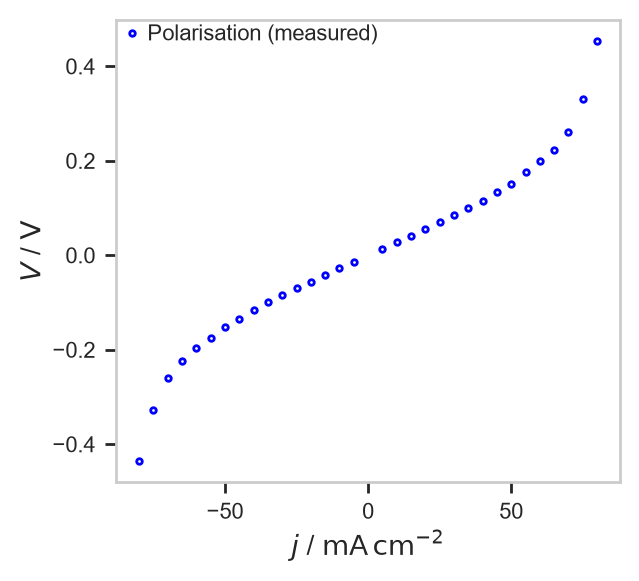

In [27]:
PolarisationData_object.label = "Polarisation (measured)"
data_plot = PolarisationPlot(figsize=(3.25, 3), dpi=200) 
data_plot.add_plot(PolarisationData_object, linestyle = "", marker = "o", markersize = 2, markerfacecolor = 'none', markeredgecolor = 'blue', color = 'blue')#, label="data")

data_plot.ax.legend()
display(data_plot.fig)

## Fitting ASR
redoxED supports extracting linear polarisation resistance from Polarisation data.
A line is fit through the data, which can be restricted to pass through (0,0) (not typically required) or use a limited j range (recommended to use only linear region).

Results of fit:
ASR = 2.717 ± 0.001 Ω cm²
Intercept = -5.4152216762304306e-05 V


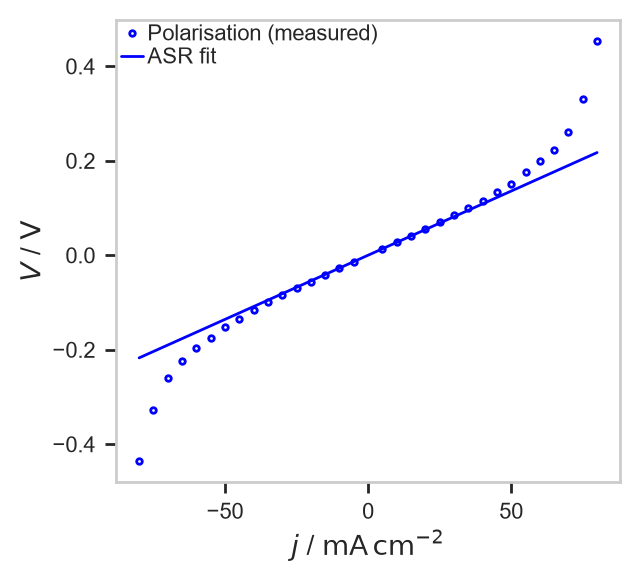

In [39]:
PolarisationData_object.calculate_ASR(restrict_to_zero=False, j_range=(-10,10))

print("Results of fit:")
print("ASR = {:.3f} ± {:.3f} Ω cm²".format(PolarisationData_object.ASR, PolarisationData_object.ASR_error))
print("Intercept = {} V".format(PolarisationData_object.ASR_intercept))

# generate plot of ASR fit
data_plot = PolarisationPlot(figsize=(3.25, 3), dpi=200) 
data_plot.add_plot(PolarisationData_object, linestyle = "", marker = "o", markersize = 2, markerfacecolor = 'none', markeredgecolor = 'blue', color = 'blue')#, label="data")
j_pred = np.sort(PolarisationData_object.j)
V_pred = PolarisationData_object.ASR*j_pred/1000 # account for mA
PolarisationData_object_fit = PolarisationData(j=j_pred, V=V_pred, A=5)
data_plot.add_plot(PolarisationData_object_fit, linestyle = "-", marker = "", linewidth = 1, color = 'blue', label = "ASR fit")


# data_plot.ax.set_xlim([0, None])
# data_plot.ax.set_ylim([0, None])


data_plot.ax.legend()
display(data_plot.fig)